# H2O AutoML

<div style="text-align: center;"><img src=".//Images//h2o-automl-logo.png" alt="h2o-automl" width="200" height="200" style="margin: 10px; "/></div>

**H2O AutoML** to otwartoźródłowa platforma automatycznego uczenia maszynowego opracowana przez firmę H2O.ai. Umożliwia automatyzację całego procesu budowy modeli ML — od wstępnego przetwarzania danych, przez trening i strojenie modeli, aż po tworzenie zespołów modeli (ensemble) i ocenę ich wydajności.

---

**Kluczowe cechy H2O AutoML**

* **Automatyczne trenowanie wielu modeli**: obsługuje różne algorytmy, takie jak GLM, GBM, Random Forest, Deep Learning i XGBoost.
* **Strojenie hiperparametrów**: wykorzystuje metody takie jak grid search i random search do optymalizacji parametrów modeli.
* **Tworzenie zespołów modeli (stacked ensembles)**: łączy najlepsze modele w celu poprawy ogólnej wydajności.
* <b style="color:red;">**Wyjaśnialność modeli**</b>: oferuje narzędzia do interpretacji wyników, takie jak analiza ważności zmiennych.
* **Interfejsy użytkownika**: dostępny przez API w językach Python i R oraz przez interfejs webowy H2O Flow.
* **Obsługa dużych zbiorów danych**: możliwość skalowania na klastrach Hadoop, Spark czy Kubernetes.

**H20 wspiera obecnie następujące algorytmy**: AdaBoost, Aggregator, ANOVA GLM, AutoML, Cox Proportional Hazards (CoxPH), Decision Tree, Deep Learning, Distributed Random Forest (DRF), Distributed Uplift Random Forest (Uplift DRF), Extended Isolation Forest, Generalized Additive Models (GAM), Generalized Linear Model (GLM), Generalized Low Rank Models (GLRM), Gradient Boosting Machine (GBM), Information Diagram (Infogram), Isolation Forest, Isotonic Regression, K-Means Clustering, ModelSelection, Naïve Bayes Classifier, Principal Component Analysis (PCA), RuleFit, Stacked Ensemble, Support Vector Machine (PSVM), Target Encoding, Word2Vec, XGBoost.

**Instalacja**:
* `pip install h2o` (ok. 270MB)
* https://docs.h2o.ai/h2o/latest-stable/h2o-docs/downloading.html

Uwaga: H2O nie wspiera algorytmu XGBoost na systemie Windows, nawet jeśli xgboost jest zainstalowany w środowisku Conda. Wynika to z tego, że moduł H2OXGBoostEstimator w H2O wymaga natywnych bibliotek kompilowanych pod Linux. Jeśli bez systemu Linux, to Colab obsługuje h2o i umożliwia używanie XGBoost w H2O AutoML.

**Źródła**:

* https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html
* https://h2o.ai/platform/h2o-automl/
* https://towardsdatascience.com/automated-machine-learning-with-h2o-258a2f3a203f/

**Licencja**:
Apache License 2.0, na której oparty jest H2O, pozwala na dowolne użycie, modyfikację i rozpowszechnianie oprogramowania, także w projektach komercyjnych. Wymaga zachowania informacji o licencji i autorach, opisania wprowadzonych zmian oraz zakazuje wykorzystywania nazwy projektu w celach promocyjnych bez zgody. Licencja nie udziela żadnej gwarancji – korzystasz z oprogramowania na własne ryzyko.

## Przygotowanie systemu H20

Import wymaganych pakietów:

In [1]:
import h2o
from h2o.automl import H2OAutoML

Sprawdzenie, czy jest dostępny XGBoost:

Inicjalizacja klastra H2O (warto spradzić, co jest pod wyświetlającym się linkiem):

In [2]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Microsoft-25199 (build 11.0.12+7, mixed mode)
  Starting server from C:\Users\ksmol\AppData\Roaming\Python\Python312\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\ksmol\AppData\Local\Temp\tmp9hmuubnq
  JVM stdout: C:\Users\ksmol\AppData\Local\Temp\tmp9hmuubnq\h2o_ksmol_started_from_python.out
  JVM stderr: C:\Users\ksmol\AppData\Local\Temp\tmp9hmuubnq\h2o_ksmol_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Europe/Belgrade
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,1 month and 20 days
H2O_cluster_name:,H2O_from_python_ksmol_gig6p6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.961 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


## Przygotowanie danych

<div style="text-align: center;"><img src=".//Images//Bank.png" alt="Bank" width="400" height="120" style="margin: 10px; "/></div>

Wykorzystamy zbiór danych z UCI, opisujący kampanię marketingową banku, w której klientom oferowano lokatę terminową. Zmienna docelowa to „yes”, jeśli klient zgodził się na lokatę, i „no”, jeśli nie.

Źródło: https://archive.ics.uci.edu/dataset/222/bank+marketing

*Szerszy opis można znaleźć w materiałach ze spotkania o **Strojeniu modeli**.*

Wczytanie danych jako `H2OFrame`:

In [3]:
df = h2o.import_file(path='./Data/bank-additional-full.csv', sep=';')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


Opis zbioru danych — H2O wyświetla przykładowe 10 wierszy oraz podstawowe statystyki dla kolumn numerycznych:

* **Chunk compression summary** – pokazuje, jak dane w kolumnach są wewnętrznie kompresowane i przechowywane w pamięci (np. liczba tzw. "chunków", czyli bloków danych przechowywanych w pamięci (zwykle ~1 000 wierszy), typy, rozmiar, kompresja),

* **Frame distribution summary** – informuje, jak dane są podzielone między węzły klastra H2O (ważne przy pracy rozproszonej),

* **Statistics** – zawiera podstawowe statystyki opisowe dla każdej kolumny: min, max, średnia, odchylenie standardowe, liczba braków, percentyle.

In [4]:
df.describe(chunk_summary=True)

Rows:41188
Cols:21

Chunk compression summary: 
chunk_type    chunk_name                 count    count_percentage    size      size_percentage
------------  -------------------------  -------  ------------------  --------  -----------------
C0L           Constant long              93       13.8393             7,3 KB    1.11407
C0D           Constant double            87       12.9464             6,8 KB    1.0422
CBS           Binary                     35       5.20833             7,9 KB    1.2123
CXI           Sparse Integers            52       7.7381              12,2 KB   1.86667
C1N           1-Byte Integers (w/o NAs)  294      43.75               389,3 KB  59.6932
C1S           1-Byte Fractions           47       6.99405             63,0 KB   9.65453
C2            2-Byte Integers            46       6.84524             118,9 KB  18.2354
C2S           2-Byte Fractions           18       2.67857             46,8 KB   7.18157

Frame distribution summary: 
                 size      number_of_rows    number_of_chunks_per_column    number_of_chunks
---------------  --------  ----------------  -----------------------------  ------------------
127.0.0.1:54321  652,2 KB  41188             32                             672
mean             652,2 KB  41188             32                             672
min              652,2 KB  41188             32                             672
max              652,2 KB  41188             32                             672
stddev           0  B      0                 0                              0
total            652,2 KB  41188             32                             672

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
type,int,enum,enum,enum,enum,enum,enum,enum,enum,enum,int,int,int,int,enum,real,real,real,real,real,enum
mins,17.0,,,,,,,,,,0.0,1.0,0.0,0.0,,-3.4,92.201,-50.8,0.634,4963.6,
mean,40.02406040594348,,,,,,,,,,258.2850101971447,2.567592502670681,962.4754540157328,0.17296299893172778,,0.08188550063125201,93.57566436826262,-40.50260027192386,3.6212908128581147,5167.035910944936,
maxs,98.0,,,,,,,,,,4918.0,56.0,999.0,7.0,,1.4,94.767,-26.9,5.045,5228.1,
sigma,10.421249980934045,,,,,,,,,,259.27924883646483,2.770013542902328,186.91090734474184,0.4949010798392899,,1.5709597405170252,0.5788400489541086,4.628197856174546,1.734447404851267,72.25152766826211,
zeros,0,,,,,,,,,,4,0,15,35563,,0,0,0,0,0,
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,149.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,226.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Usunięcie cechy 'duration', która może sugerować wynik:

In [5]:
df = df.drop('duration')

W H2O AutoML wybór klasyfikacji vs regresji odbywa się automatycznie na podstawie typu zmiennej docelowej (y) przekazanej do metody .train(). Aby H2O potraktowało problem jako klasyfikacyjny, trzeba upewnić się, że kolumna docelowa (y) ma typ kategoryczny (factor) w H2OFrame.

In [6]:
# Ustaw zmienną docelową jako 'factor' (czyli kategoria)
df['y'] = df['y'].asfactor()

Podział zbioru danych na zbiór treningowy i testowy:

In [7]:
train, test = df.split_frame(ratios=[0.8], seed=42)

## Trenowanie modeli

Konfiguracja parametrów treningu:

* `max_models`: maksymalna liczba trenowanych modeli
* `balance_classes`: ustawienie na `True` powoduje zbalansowanie klas
* `seed`: ustawia losowość dla odtwarzalności wyników

oraz parametry związane z czasem obliczeń:

* `max_runtime_secs` – limit czasu na całą procedurę AutoML
* `max_runtime_secs_per_model` – limit czasu na każdy pojedynczy model

In [8]:
aml = H2OAutoML(
    max_models=25, 
    balance_classes=True, 
    seed=42,
    max_runtime_secs=120, # 2 minuty
    exclude_algos=["XGBoost"] # w innym przypadku będzie w Windows warning, przy uruchomieniu .train
)

Rozpoczęcie treningu (jeśli model = ... będzie mniej informacji zwrotnych).

Uwagi:



* **training_frame=train** – model uczy się na tych danych.
* **leaderboard_frame=test** – używany tylko do końcowej oceny modeli i budowy leaderboardu
* opcjonalnie można podać **validation_frame**, czyli ramkę danych do oceny modelu w czasie treningu, jeśli nie zostanie podana, H2O użyje walidacji krzyżowej (k-fold, domyślnie nfolds=5), która posłuży do :
  * oceny poszczególnych modeli podczas selekcji (np. wyboru najlepszego GBM),
  * konstrukcji modeli ensemble (np. Stacked Ensemble korzysta z predykcji CV),
  * przy braku **leaderboard_frame=test**, test robiony jest poprzez walidację krzyżową.

In [9]:
aml.train(training_frame=train, y='y')

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_5_AutoML_1_20250517_174238


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    38                 38                          30404                  6            6            6             45            64            59.0789

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.26694756135194125
RMSE: 0.5166696830199554
LogLoss: 0.8187174088279281
Mean Per-Class Error: 0.2398412786705501
AUC: 0.8520136038027845
AUCPR: 0.8666695349775297
Gini: 0.7040272076055689

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.06562369917621626
       no     yes    Error    Rate
-----  -----  -----  -------  -----------------
no     21102  8277   0.2817   (8277.0/29379.0)
yes    5815   23561  0.198    (5815.0/29376.0)
Total  26917  31838  0.2398   (14092.0/58755.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.0656237    0.769791  328
max f2                       0.0342516    0.851813  376
max f0point5                 0.147679     0.810964  270
max accuracy                 0.0895713    0.774726  304
max precision                0.780481     1         0
max recall                   0.0204078    1         393
max specificity              0.780481     1         0
max absolute_mcc             0.137948     0.561318  275
max min_per_class_accuracy   0.0731988    0.765863  320
max mean_per_class_accuracy  0.0895713    0.774722  304
max tns                      0.780481     29379     0
max fns                      0.780481     29368     0
max fps                      0.0101732    29379     399
max tps                      0.0204078    29376     393
max tnr                      0.780481     1         0
max fnr                      0.780481     0.999728  0
max fpr                      0.0101732    1         399
max tpr                      0.0204078    1         393

Gains/Lift Table: Avg response rate: 50,00 %, avg score: 19,61 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100587                   0.749531           2.0001    2.0001             1                0.758679   1                           0.758679            0.0201185       0.0201185                  100.01    100.01             0.0201185
2        0.0200834                   0.733845           1.97973   1.98993            0.989813         0.741545   0.994915                    0.750126            0.0198461       0.0399646                  97.9728   98.9932            0.0397604
3        0.0301251                   0.713546           1.95264   1.9775             0.976271         0.724349   0.988701                    0.741534            0.0196078       0.0595724                  95.2642   97.7502            0.0588917
4        0.0400987                   0.694974           1.96597   1.97463            0.982935         0.703836   0.987267                    0.732157            0.0196078       0.0791803                  96.5971   97.4634            0.0781591
5        0.0500894                   0.673764           1.96262   1.97224            0.981261         0.684867   0.986069    

### Co dzieje się w czasie treningu?

H2O AutoML trenuje i waliduje następujące modele (w podanej kolejności):

* trzy predefiniowane modele XGBoost (ale nie w Windows),
* ustaloną siatkę (grid search) modeli GLM,
* domyślny Random Forest (DRF),
* pięć predefiniowanych modeli H2O GBM,
* domyślną sieć neuronową,
* Extremely Randomized Forest (XRT),
* losową siatkę (randomized grid search) XGBoost GBM (ale nie w Windows),
* losową siatkę (randomized grid search) H2O GBM,
* losową siatkę (randomized grid search) głębokich sieci neuronowych.

Dodatkowo tworzone są:

* zespół modeli (stacked ensemble) z powyższych
* „Best of Family” ensemble z najlepszymi modelami z każdej grupy algorytmów

### Co otrzymujemy?

**Model Details** z nazwą wybranego estymatora oraz kolejne zestawienia (dla klasyfikacji):
* **Model Summary**: Podsumowanie architektury i ustawień modelu: liczba drzew, głębokość, czas treningu, hiperparametry itp.
* **Confusion Matrix (Act/Pred)**: Macierz pomyłek pokazująca, ile przykładów rzeczywistej klasy zostało przypisanych do każdej klasy przewidywanej — dobra do oceny klasyfikacji.
* **Maximum Metrics**: Zestaw różnych metryk (AUC, F1, Accuracy, MCC itd.) obliczonych przy wielu progach prawdopodobieństwa — z oznaczeniem wartości maksymalnych i odpowiadających im progów.
* **Gains/Lift Table**: Tabela efektywności klasyfikatora — pokazuje, jak model identyfikuje pozytywne przypadki w kolejnych procentach populacji (np. w top 10% wyników modelu mamy x% prawdziwych pozytywnych przypadków).
    * **Avg response rate** – udział pozytywnych przypadków w rzeczywistych danych
    * **Avg score** – średnie przewidywane prawdopodobieństwo przez model
* **ModelMetricsBinomial**: Zestawienie metryk klasyfikacji binarnej (dla wybranego modelu): AUC, LogLoss, F1, Accuracy, MCC, Gini, TPR, TNR itp.
* **Confusion Matrix (Act/Pred) for max F1**: Macierz pomyłek obliczona przy progu, dla którego F1-score był największy — użyteczna do optymalizacji klasyfikatora.
* **Cross-Validation Metrics Summary**: Średnie metryki uzyskane na podstawie walidacji krzyżowej (k-fold CV): AUC, LogLoss, RMSE itd., z dodatkowymi informacjami o wariancji (sd).
* **Scoring History**: Historia wydajności modelu podczas treningu — np. LogLoss, AUC czy inne metryki w kolejnych iteracjach (np. kolejnych drzewach GBM).
* **Variable Importances**: Ważność cech według modelu – wskazuje, które zmienne miały największy wpływ na predykcje (suma = 100%).

### Iterpretacja otrzymanego modelu

UWAGA: *Ze względu na losowość dużej części algorytmów i ich dostępność (XGBoost) oraz narzucony czas, wyniki mogą się  różnić.*

**Interpretacja wyników modelu** `GBM_5_AutoML_1_20250517_174238` (H2O Gradient Boosting Machine)

**Struktura modelu**

* **Liczba drzew**: 38 – umiarkowana liczba, sugeruje model o ograniczonej złożoności.
* **Średnia głębokość drzewa**: 6 – zapewnia kompromis między dopasowaniem a generalizacją.
* **Średnia liczba liści**: ok. 59 – drzewo nie jest nadmiernie rozgałęzione.

---

**Jakość dopasowania (dane treningowe)**

* **AUC: 0.85** – bardzo dobry poziom rozróżnienia między klasami.
* **LogLoss: 0.82** – akceptowalna entropia błędu, nie przeucza.
* **RMSE: 0.52**, **MSE: 0.27** – typowe wartości dla klasyfikacji binarnej.
* **Średni błąd klas**: \~24% – wskazuje, że model lepiej przewiduje jedną klasę niż drugą.

---

**Najlepszy próg (threshold \~0.066) – maks. F1 = 0.77**

* **Precyzja (precision): 1.0 przy threshold 0.78** – bardzo wysoka, ale kosztem czułości (recall).
* **Czułość (recall): 1.0 przy bardzo niskim progu** – typowe dla modeli o dużej przewadze jednej klasy.
* **Accuracy (max): 0.77 przy progu 0.0895** – zgodność predykcji z etykietą.

---

**Macierz pomyłek (train, przy max F1)**

* **Błąd klasy „no”**: 28,2%
* **Błąd klasy „yes”**: 19,8%
* Ogólny błąd: **23,98%**

---

**Lift / Gains**

* **Lift w top 1% danych: \~2.0** – bardzo wysokie zagęszczenie pozytywów w najwyżej punktowanych obserwacjach.
* **Wartość Kolmogorov-Smirnova: \~0.55** – bardzo dobre rozróżnienie klas (granica akceptowalności to 0.2).

---

**Wyniki walidacji krzyżowej**

* **AUC: 0.80**, **F1: 0.50**, **Accuracy: 0.88** – wskazują na dobrą ogólną jakość modelu.
* **Precision: 0.46**, **Recall: 0.56** – solidne zrównoważenie metryk, błąd typu II nie jest przesadnie wysoki.
* **LogLoss: 0.27** – lepszy niż na treningu → brak przeuczenia.

---

**Ważność cech**

* **euribor3m (37%)** – stopy procentowe są głównym czynnikiem wpływającym na decyzję o lokacie.
* **nr.employed (25%)** – ogólna liczba zatrudnionych → sytuacja ekonomiczna.
* **month, job, pdays, day\_of\_week** – dane związane z kampanią i socjodemografią.
* **cechy mniej istotne**: `loan`, `housing`, `previous` – ich wpływ na decyzję jest marginalny.

---

***Wnioski**:

Model GBM uzyskany przez H2O AutoML charakteryzuje się wysoką jakością predykcji i stabilnością ocen między treningiem a walidacją. Zmienna `euribor3m` dominuje w ważności cech, a wartość wskaźnika Kolmogorova-Smirnova i AUC potwierdzają bardzo dobre rozróżnienie klas. Model jest użyteczny do przewidywania odpowiedzi klientów na ofertę lokaty terminowej.

---

**Przyjrzyjmy się głębiej w interpretację zmiennych:**

* **euribor3m** = 37,3% → Stopa procentowa – kluczowy czynnik wpływający na decyzję o lokacie
* **nr.employed** = 24,8% → Liczba zatrudnionych – odzwierciedla kondycję rynku pracy, silnie powiązana z decyzjami klientów
* **month** = 11,7% → Miesiąc kontaktu – efekt sezonowości, promocji lub kampanii okresowych
* **job** = 4,9% → Typ zawodu – silna cecha socjoekonomiczna klienta
* **pdays** = 3,1% → Liczba dni od poprzedniego kontaktu – istotna dla identyfikacji klientów uprzednio zainteresowanych
* **day\_of\_week** = 2,8% → Dzień tygodnia – może wpływać na dyspozycyjność lub nastrój klienta
* **cons.conf.idx** = 2,3% → Wskaźnik zaufania konsumenckiego – pośredni sygnał nastawienia klienta
* **education** = 2,0% → Wykształcenie – potencjalnie powiązane z decyzjami inwestycyjnymi
* **age** = 2,0% → Wiek – może różnicować preferencje dotyczące oszczędzania
* **campaign** = 1,8% → Liczba kontaktów w danej kampanii – wpływa na skuteczność dotarcia do klienta

## Ocena

Po treningu można porównać modele za pomocą tzw. leaderboarda:

In [10]:
lb = aml.leaderboard
lb.head(rows=lb.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GBM_5_AutoML_1_20250517_174238,0.799345,0.271091,0.464535,0.262528,0.276919,0.0766843
GBM_2_AutoML_1_20250517_174238,0.797924,0.271858,0.466771,0.2672,0.277013,0.0767363
GLM_1_AutoML_1_20250517_174238,0.793529,0.2733,0.455581,0.272827,0.277781,0.0771625
GBM_1_AutoML_1_20250517_174238,0.792412,0.274943,0.467046,0.264719,0.27697,0.0767123
GBM_3_AutoML_1_20250517_174238,0.792277,0.275004,0.462272,0.266336,0.27812,0.0773506
XRT_1_AutoML_1_20250517_174238,0.790199,0.298221,0.445576,0.278686,0.289542,0.0838344
GBM_4_AutoML_1_20250517_174238,0.782257,0.283178,0.446409,0.276972,0.281626,0.0793133
DeepLearning_1_AutoML_1_20250517_174238,0.776741,0.282263,0.424667,0.274376,0.281025,0.0789751
DRF_1_AutoML_1_20250517_174238,0.773519,0.323822,0.406907,0.293923,0.293625,0.0862157


Pobranie najlepszego modelu i jego ocena:

In [11]:
best_model = aml.get_best_model()
print(best_model)

Model Details
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_5_AutoML_1_20250517_174238


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    38                 38                          30404                  6            6            6             45            64            59.0789

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.26694756135194125
RMSE: 0.5166696830199554
LogLoss: 0.8187174088279281
Mean Per-Class Error: 0.2398412786705501
AUC: 0.8520136038027845
AUCPR: 0.8666695349775297
Gini: 0.7040272076055689

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.06562369917621626
       no     yes    Error    Rate
-----  -----  -----  -------  -----------------


Ocena modelu:

In [12]:
best_model.model_performance(test)

ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.08278814523317306
RMSE: 0.28772929158007715
LogLoss: 0.28935631054138733
Mean Per-Class Error: 0.25955115388788147
AUC: 0.7908608180456207
AUCPR: 0.44201422654773
Gini: 0.5817216360912414

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.14066803534477076
       no    yes    Error    Rate
-----  ----  -----  -------  ---------------
no     6470  699    0.0975   (699.0/7169.0)
yes    406   557    0.4216   (406.0/963.0)
Total  6876  1256   0.1359   (1105.0/8132.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.140668     0.502028  234
max f2                       0.0924657    0.554854  269
max f0point5                 0.361676     0.499846  134
max accuracy                 0.472866     0.894122  87
max precision                0.684709     0.761905  24
max recall                   0.0151473    1         395
max specificity              0.775165     0.999861  0
max absolute_mcc             0.140668     0.429964  234
max min_per_class_accuracy   0.0662435    0.717549  304
max mean_per_class_accuracy  0.0924657    0.744339  269
max tns                      0.775165     7168      0
max fns                      0.775165     962       0
max fps                      0.00781664   7169      399
max tps                      0.0151473    963       395
max tnr                      0.775165     0.999861  0
max fnr                      0.775165     0.998962  0
max fpr                      0.00781664   1         399
max tpr                      0.0151473    1         395

Gains/Lift Table: Avg response rate: 11,84 %, avg score: 10,14 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100836                   0.685078           6.38482   6.38482            0.756098         0.730967   0.756098                    0.730967            0.0643821       0.0643821                  538.482   538.482            0.0615923
2        0.0200443                   0.571268           5.42112   5.90593            0.641975         0.629919   0.699387                    0.680753            0.0539979       0.11838                    442.112   490.593            0.111545
3        0.0300049                   0.50277            5.62963   5.81421            0.666667         0.534229   0.688525                    0.632112            0.0560748       0.174455                   462.963   481.421            0.163854
4        0.0400885                   0.451014           4.42818   5.46558            0.52439          0.477319   0.647239                    0.593176            0.0446521       0.219107                   342.818   446.558            0.203066
5        0.0500492                   0.412867           4.27435   5.2285             0.506173         0.430032   0.619165                    0.560708            0.0425753       0.261682                   327.435   422.85             0.240061
6        0.100098                    0.309374           3.31968   4.27409            0.39312          0.355758   0.506143                    0.458233            0.166147        0.42783                    231.968   327.409            0.371755
7        0.150025                    0.146454           2.82868   3.79308            0.334975         0.227718   0.44918                     0.38152             0.141225        0.569055                   182.868   279.308            0.475318
8        0.200074     

## Zapis, odczyt i predykcja

In [13]:
import os

Zapis modelu:

In [14]:
model_path = h2o.save_model(model=best_model, path='./h20_models/bank_marketing/', force=True)
print(model_path)

C:\Users\ksmol\Anaconda\Kursy\ML 2025\Spotkanie 10 - autoML\h20_models\bank_marketing\GBM_5_AutoML_1_20250517_174238


Nazwę modelu trzeba znać :) Można ją podejrzeć w danym katalogu, gorzej, jak wrzucamy tam więcej modeli.

In [15]:
model_name = os.path.basename(model_path)
print(model_name)

GBM_5_AutoML_1_20250517_174238


## Załadowanie modelu i predykcja:

In [16]:
# jeśli wcześniej nie utworzono:
# import h2o
# h2o.init()

In [17]:
loaded_model = h2o.load_model(path=f'./h20_models/bank_marketing/{model_name}')
loaded_model.predict(test)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


predict,no,yes
no,0.976897,0.0231025
no,0.974723,0.0252772
no,0.973249,0.0267511
no,0.972174,0.0278256
no,0.975385,0.0246149
no,0.975477,0.0245232
no,0.979258,0.0207423
no,0.970203,0.0297967
no,0.975175,0.0248252
no,0.976919,0.0230807


**Uwaga**: wersja H2O użyta do trenowania modelu musi być taka sama jak ta używana przy wnioskowaniu.

# Interpretacja modeli:

H2O AutoML oferuje globalną wyjaśnialność modeli: ważność cech, wykresy zależności, wartości SHAP, korelacje modeli (domyślnie wyjaśnienie dotyczy modelu najlepszego, czyli `aml.leader`, choć dla porównania pojawią się też inne modele - w sumie 5):

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
GBM_5_AutoML_1_20250517_174238,0.790861,0.289356,0.442014,0.259551,0.287729,0.0827881,1155,0.004881,GBM
GBM_2_AutoML_1_20250517_174238,0.787542,0.291415,0.438988,0.271586,0.288551,0.0832616,1225,0.005155,GBM
GBM_3_AutoML_1_20250517_174238,0.783337,0.29415,0.44014,0.268905,0.289447,0.0837793,1291,0.004877,GBM
GBM_1_AutoML_1_20250517_174238,0.782369,0.296152,0.436607,0.269897,0.289342,0.0837189,3420,0.006437,GBM
XRT_1_AutoML_1_20250517_174238,0.779391,0.32257,0.42223,0.278436,0.301696,0.0910203,3236,0.009003,DRF
GLM_1_AutoML_1_20250517_174238,0.777699,0.294716,0.429224,0.278049,0.290059,0.0841342,799,0.004079,GLM
DeepLearning_1_AutoML_1_20250517_174238,0.775097,0.308919,0.428817,0.296578,0.295928,0.0875733,1952,0.003414,DeepLearning
GBM_4_AutoML_1_20250517_174238,0.771558,0.304307,0.419059,0.28197,0.294054,0.086468,1388,0.005494,GBM
DRF_1_AutoML_1_20250517_174238,0.766879,0.344508,0.392797,0.299275,0.305668,0.0934331,4305,0.011636,DRF


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## GBM_5_AutoML_1_20250517_174238

,no,yes,Error,Rate
no,6470.0,699.0,0.0975,(699.0/7169.0)
yes,406.0,557.0,0.4216,(406.0/963.0)
Total,6876.0,1256.0,0.1359,(1105.0/8132.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

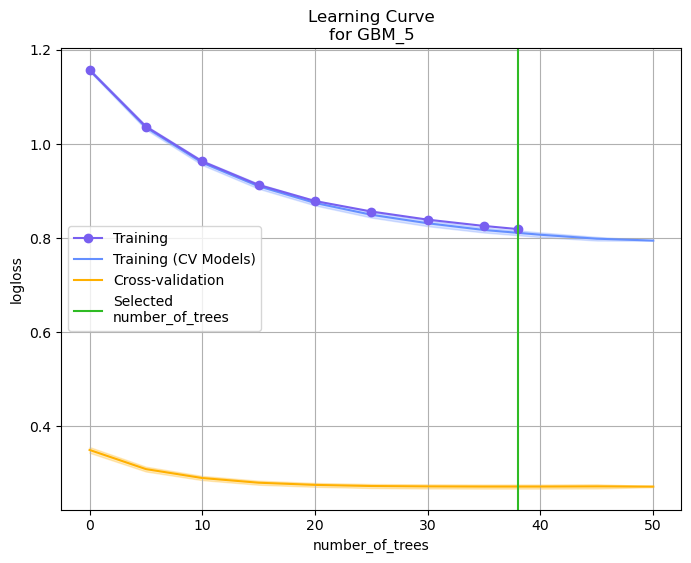

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

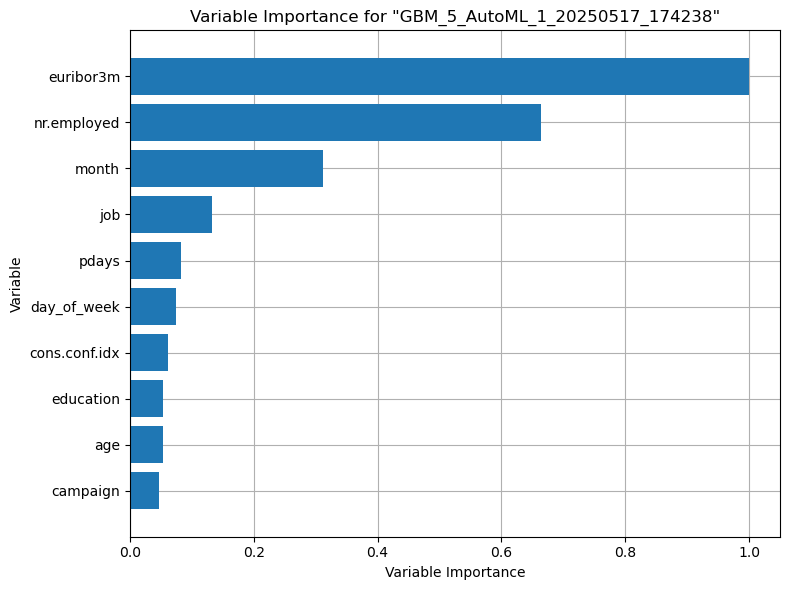

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

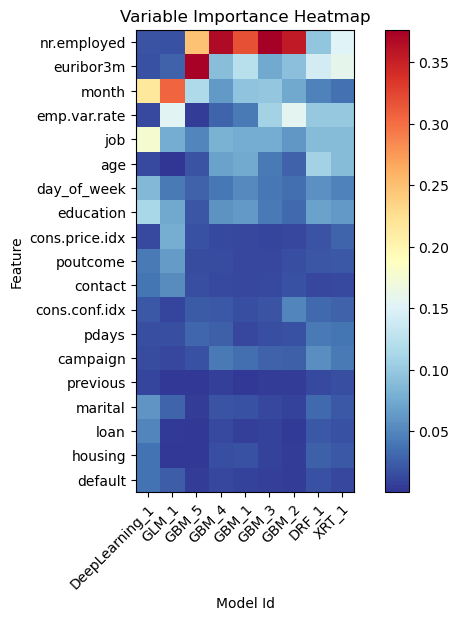

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

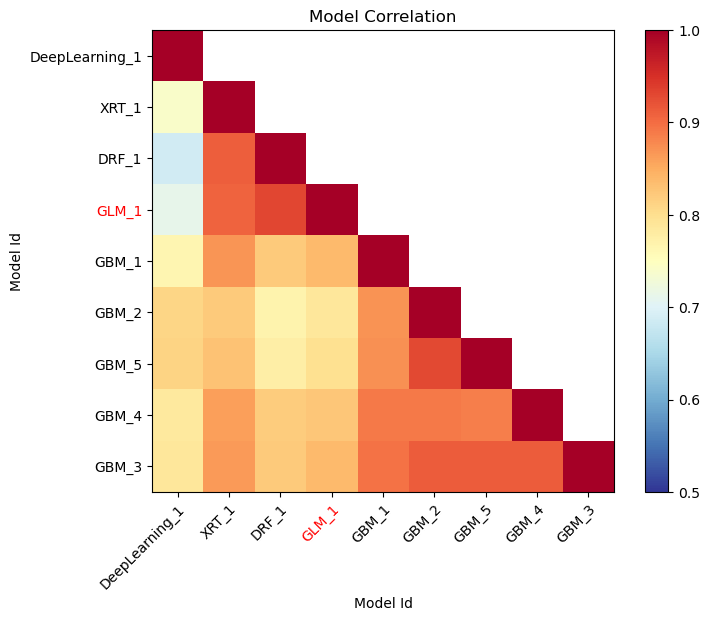

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

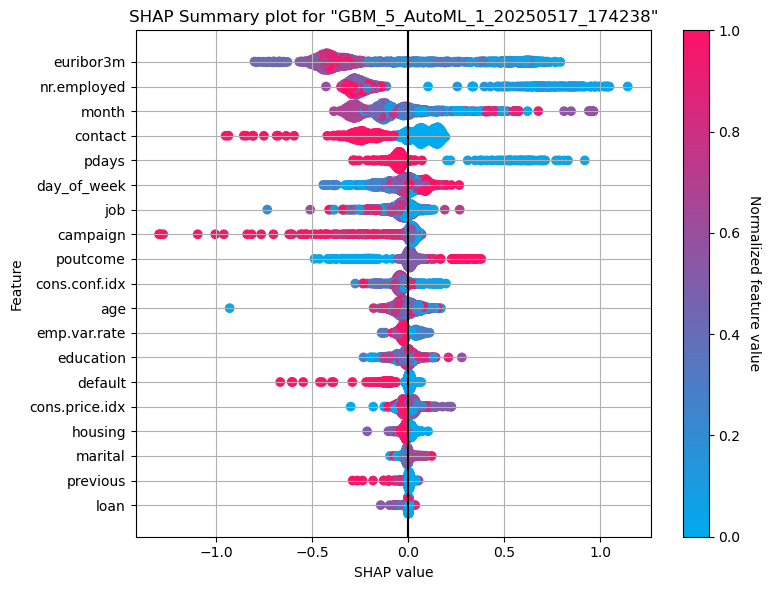

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

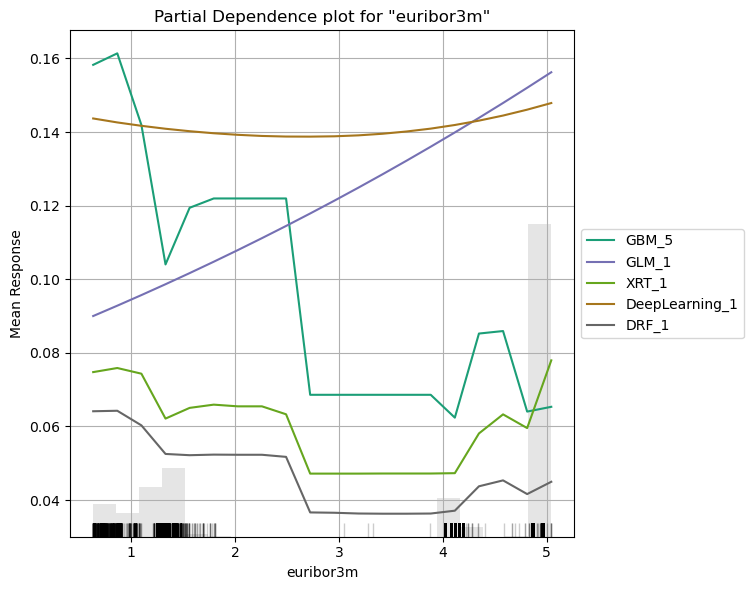

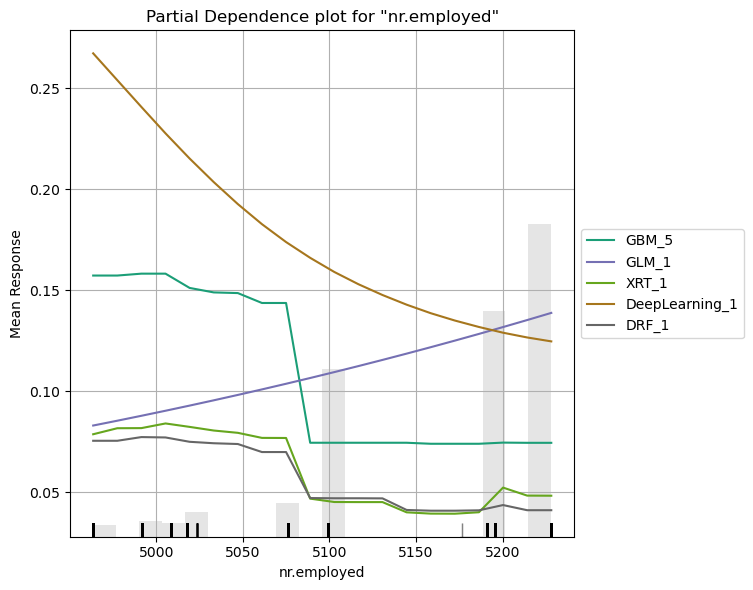

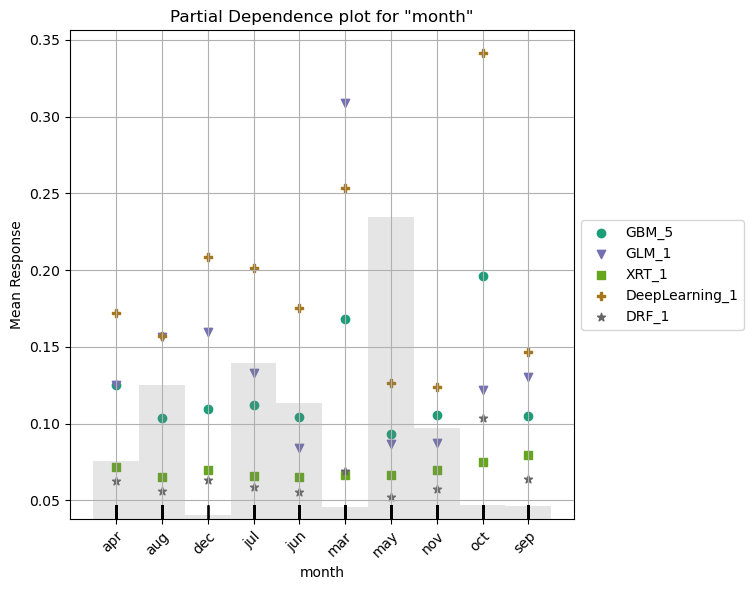

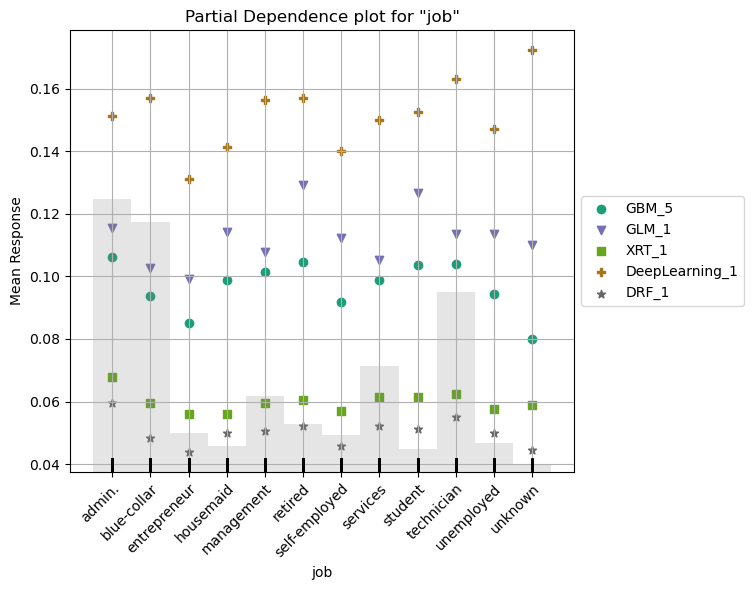

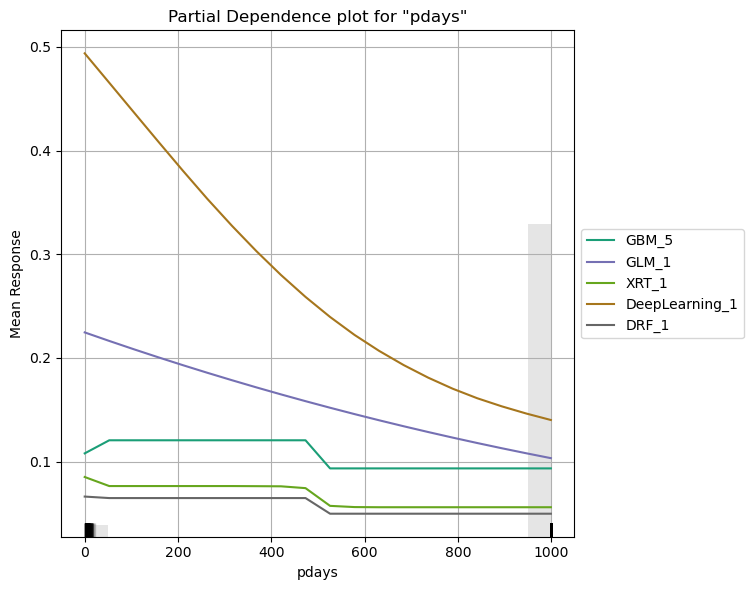

In [18]:
explain_model = aml.explain(frame=test, figsize=(8,6))

Dostępna jest także wyjaśnialność lokalna dla konkretnego wiersza:

# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,no,yes
GBM_5_AutoML_1_20250517_174238,0.790861,0.289356,0.442014,0.259551,0.287729,0.0827881,1155,0.004881,GBM,no,0.979247,0.0207533
GBM_2_AutoML_1_20250517_174238,0.787542,0.291415,0.438988,0.271586,0.288551,0.0832616,1225,0.005155,GBM,no,0.982233,0.0177673
GBM_3_AutoML_1_20250517_174238,0.783337,0.29415,0.44014,0.268905,0.289447,0.0837793,1291,0.004877,GBM,no,0.985636,0.0143641
GBM_1_AutoML_1_20250517_174238,0.782369,0.296152,0.436607,0.269897,0.289342,0.0837189,3420,0.006437,GBM,no,0.99268,0.00731969
XRT_1_AutoML_1_20250517_174238,0.779391,0.32257,0.42223,0.278436,0.301696,0.0910203,3236,0.009003,DRF,no,0.983334,0.0166662
GLM_1_AutoML_1_20250517_174238,0.777699,0.294716,0.429224,0.278049,0.290059,0.0841342,799,0.004079,GLM,no,0.970961,0.0290388
DeepLearning_1_AutoML_1_20250517_174238,0.775097,0.308919,0.428817,0.296578,0.295928,0.0875733,1952,0.003414,DeepLearning,no,0.989193,0.0108067
GBM_4_AutoML_1_20250517_174238,0.771558,0.304307,0.419059,0.28197,0.294054,0.086468,1388,0.005494,GBM,no,0.983583,0.016417
DRF_1_AutoML_1_20250517_174238,0.766879,0.344508,0.392797,0.299275,0.305668,0.0934331,4305,0.011636,DRF,no,0.994737,0.00526292


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

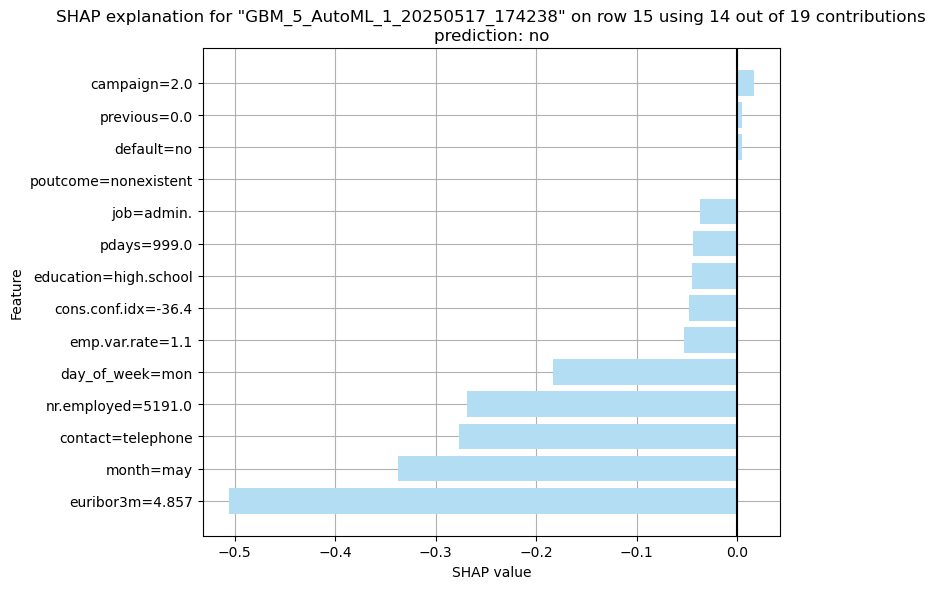

# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,no,yes
GBM_5_AutoML_1_20250517_174238,0.790861,0.289356,0.442014,0.259551,0.287729,0.0827881,1155,0.004881,GBM,no,0.979247,0.0207533
GBM_2_AutoML_1_20250517_174238,0.787542,0.291415,0.438988,0.271586,0.288551,0.0832616,1225,0.005155,GBM,no,0.982233,0.0177673
GBM_3_AutoML_1_20250517_174238,0.783337,0.29415,0.44014,0.268905,0.289447,0.0837793,1291,0.004877,GBM,no,0.985636,0.0143641
GBM_1_AutoML_1_20250517_174238,0.782369,0.296152,0.436607,0.269897,0.289342,0.0837189,3420,0.006437,GBM,no,0.99268,0.00731969
XRT_1_AutoML_1_20250517_174238,0.779391,0.32257,0.42223,0.278436,0.301696,0.0910203,3236,0.009003,DRF,no,0.983334,0.0166662
GLM_1_AutoML_1_20250517_174238,0.777699,0.294716,0.429224,0.278049,0.290059,0.0841342,799,0.004079,GLM,no,0.970961,0.0290388
DeepLearning_1_AutoML_1_20250517_174238,0.775097,0.308919,0.428817,0.296578,0.295928,0.0875733,1952,0.003414,DeepLearning,no,0.989193,0.0108067
GBM_4_AutoML_1_20250517_174238,0.771558,0.304307,0.419059,0.28197,0.294054,0.086468,1388,0.005494,GBM,no,0.983583,0.016417
DRF_1_AutoML_1_20250517_174238,0.766879,0.344508,0.392797,0.299275,0.305668,0.0934331,4305,0.011636,DRF,no,0.994737,0.00526292


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

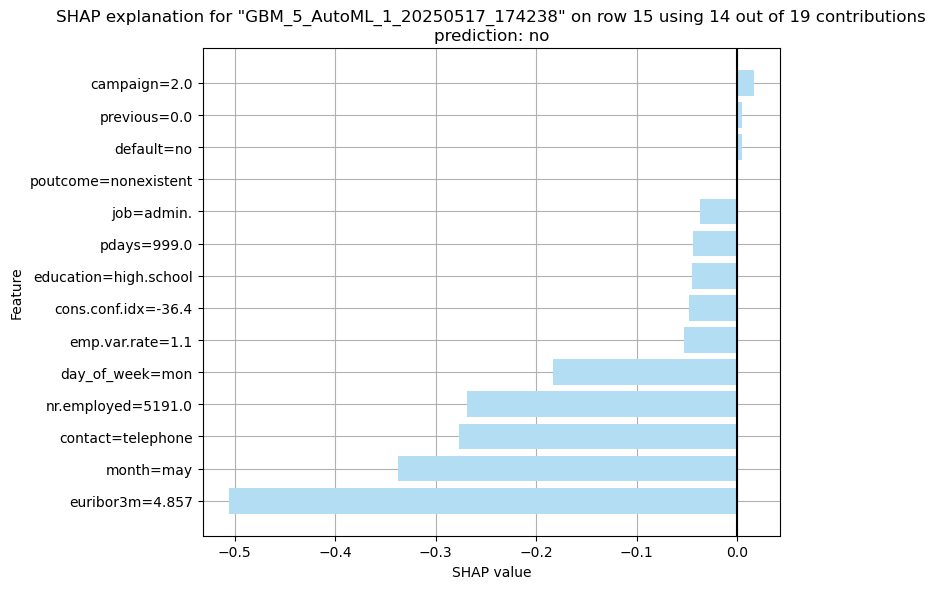

In [19]:
aml.explain_row(frame=test, row_index=15, figsize=(8,6))

#  Zakończenie sesji

In [20]:
h2o.cluster().shutdown(prompt=False) # lub z interfejsu

H2O session _sid_9ede closed.


Zakończenie sesji H2O (shutdown) jest zalecane, ponieważ H2O:
* Uruchamia własny serwer JVM (Java Virtual Machine),
* Rezerwuje zasoby systemowe, w tym RAM (H2O może zajmować kilkaset MB lub więcej RAM-u (zwłaszcza po trenowaniu modeli)) i porty sieciowe (unikanie konfliktów, szczegolnie jeśli uruchomi się `h2o.init()` bez zamknięcia poprzedniej sesji),
* Tworzy lokalny serwer HTTP, który działa w tle (domyślnie na localhost:54321).

# W skrócie

Oto **skrócony kod** do uruchomienia H2O AutoML i oceny modelu na zbiorze *Bank Marketing* z UCI:

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Microsoft-25199 (build 11.0.12+7, mixed mode)
  Starting server from C:\Users\ksmol\AppData\Roaming\Python\Python312\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\ksmol\AppData\Local\Temp\tmpwv4c81wb
  JVM stdout: C:\Users\ksmol\AppData\Local\Temp\tmpwv4c81wb\h2o_ksmol_started_from_python.out
  JVM stderr: C:\Users\ksmol\AppData\Local\Temp\tmpwv4c81wb\h2o_ksmol_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Europe/Belgrade
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,1 month and 20 days
H2O_cluster_name:,H2O_from_python_ksmol_1jhmtz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.961 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
19:29:19.824: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
AUC: 0.7823693423296074
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.1736411967509028
       no    yes    Error    Rate
-----  ----  -----  -------  ---------------
no     6545  624    0.087    (624.0/7169.0)
yes    436   527    0.4528   (436.0/963.0)
Total  6981  1151   0.1303   (1060.0/8132.0)


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## GBM_1_AutoML_1_20250517_192919

,no,yes,Error,Rate
no,6545.0,624.0,0.087,(624.0/7169.0)
yes,436.0,527.0,0.4528,(436.0/963.0)
Total,6981.0,1151.0,0.1303,(1060.0/8132.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

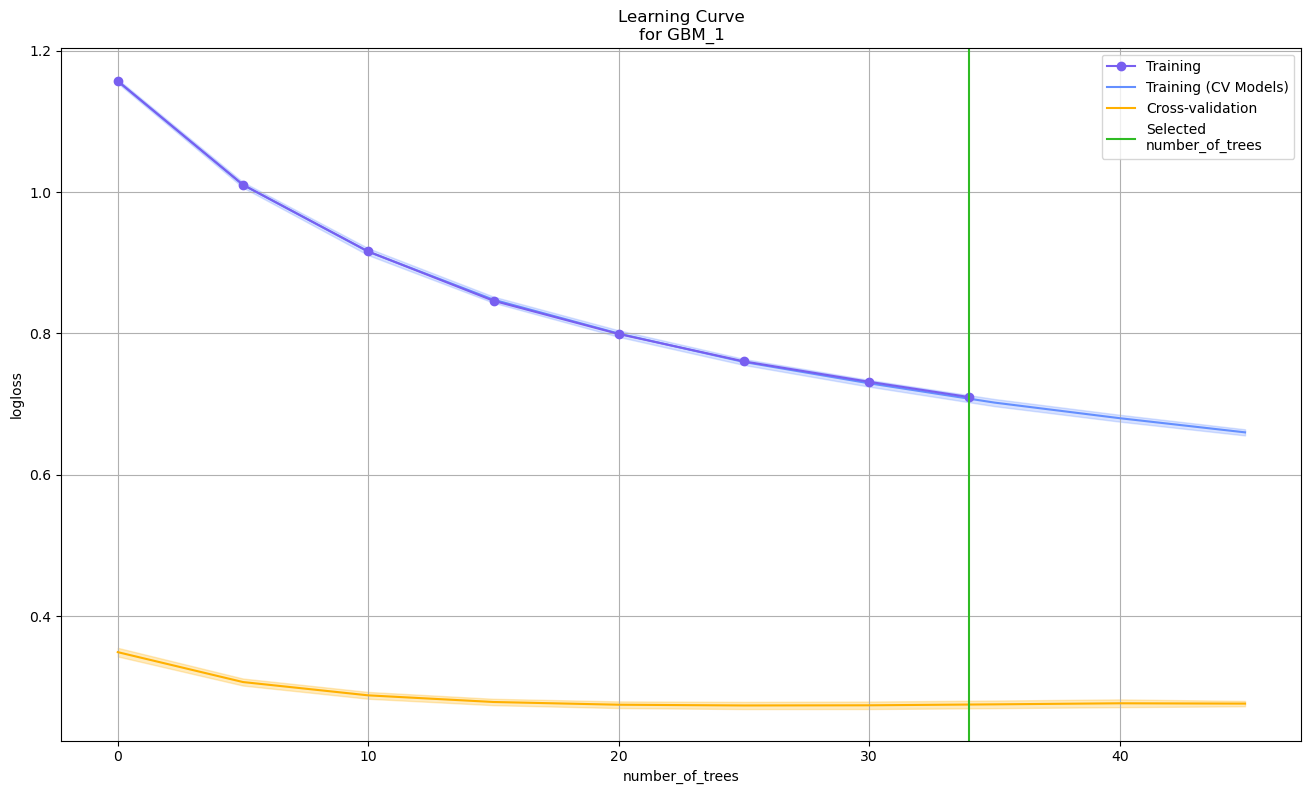

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

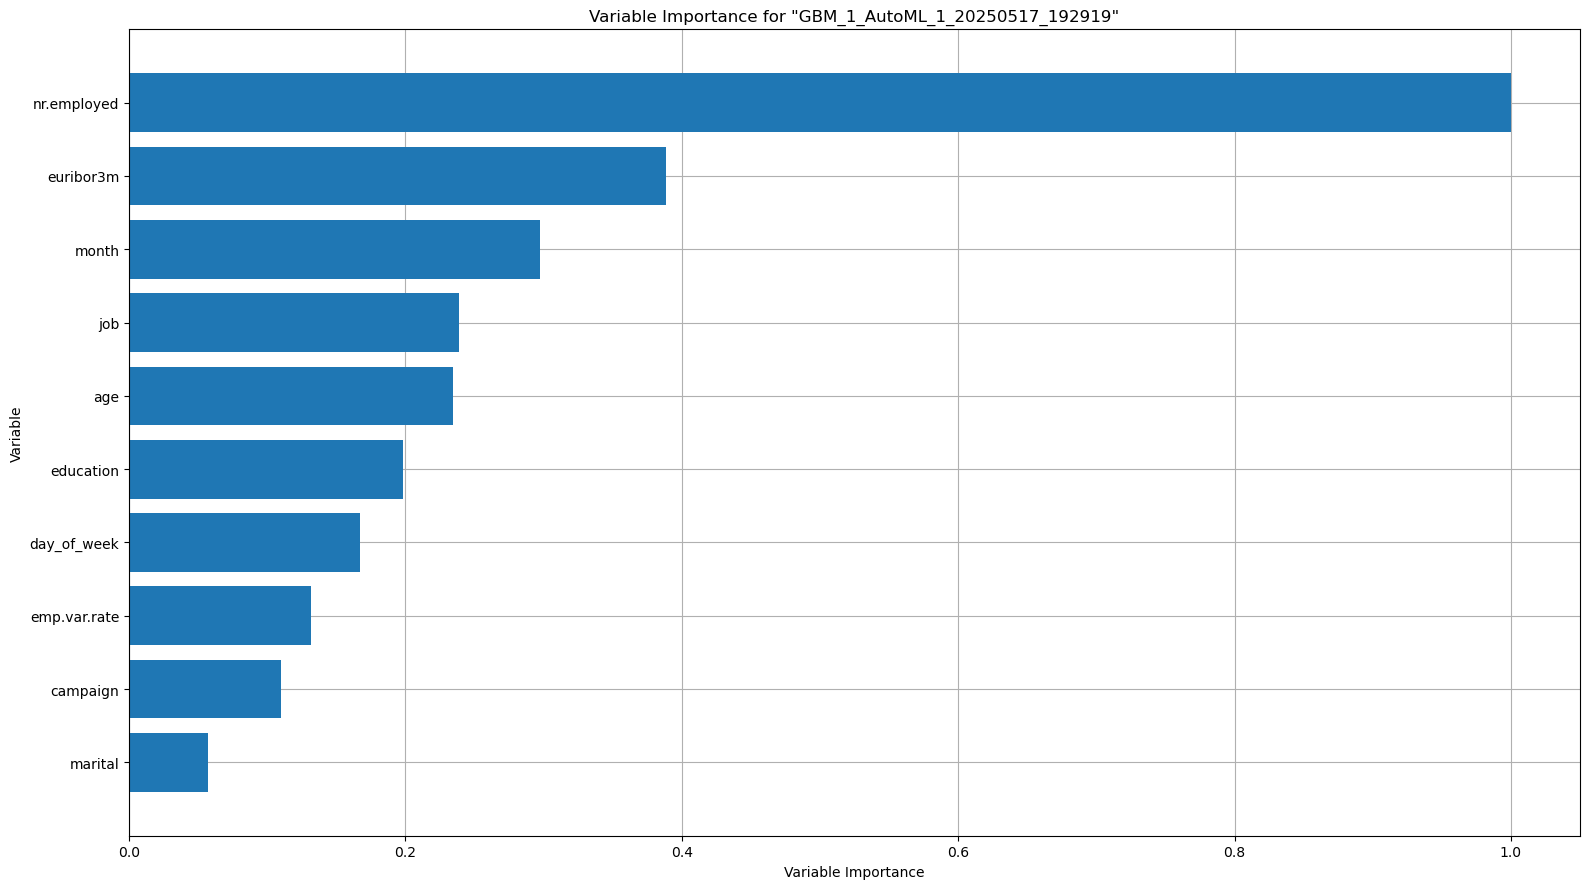

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

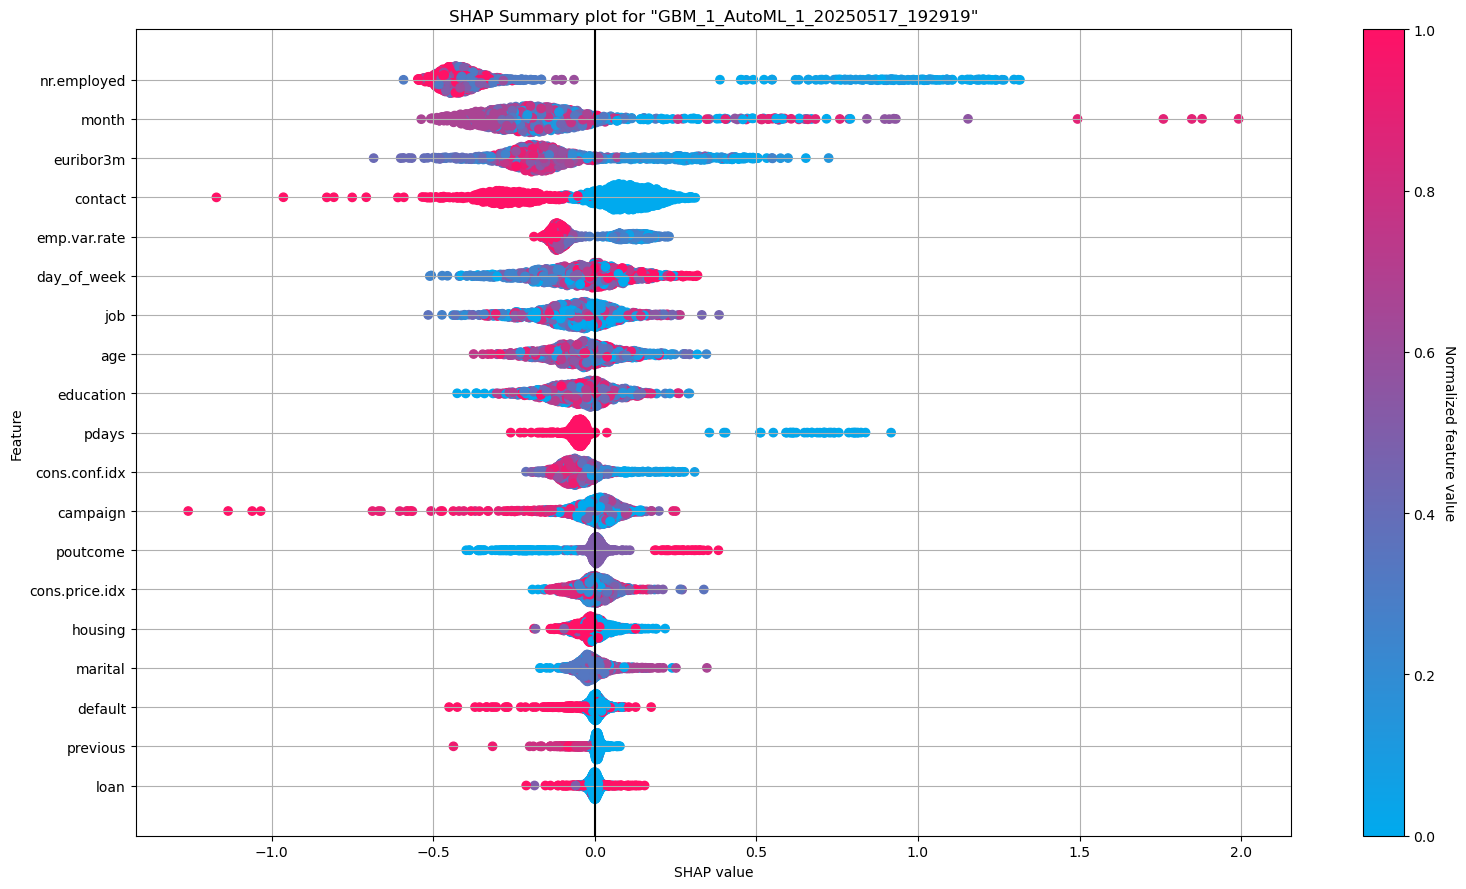

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

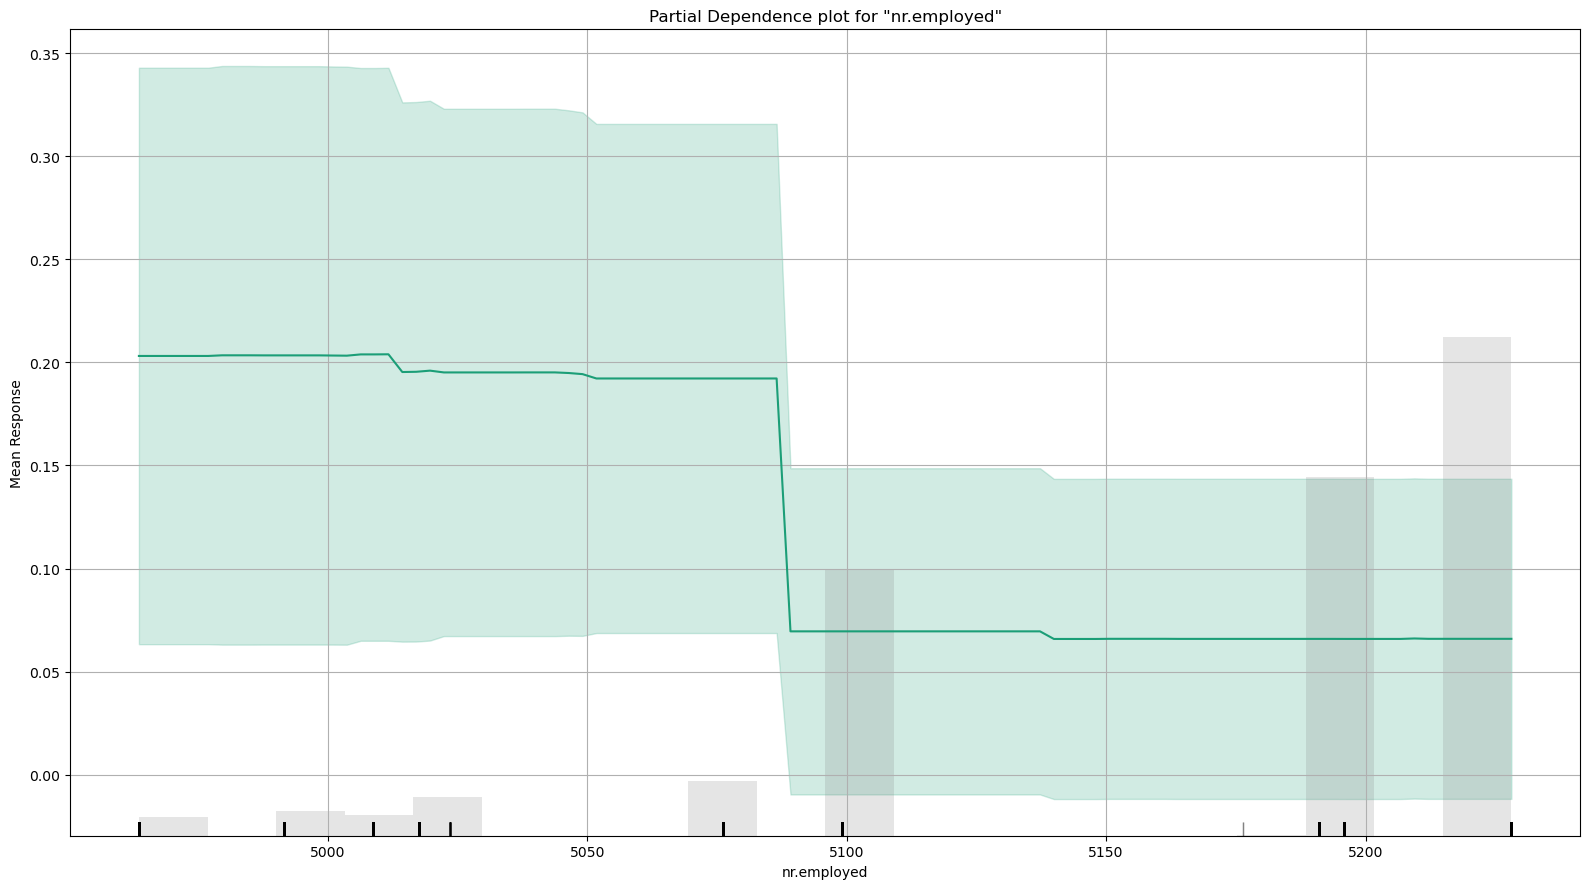

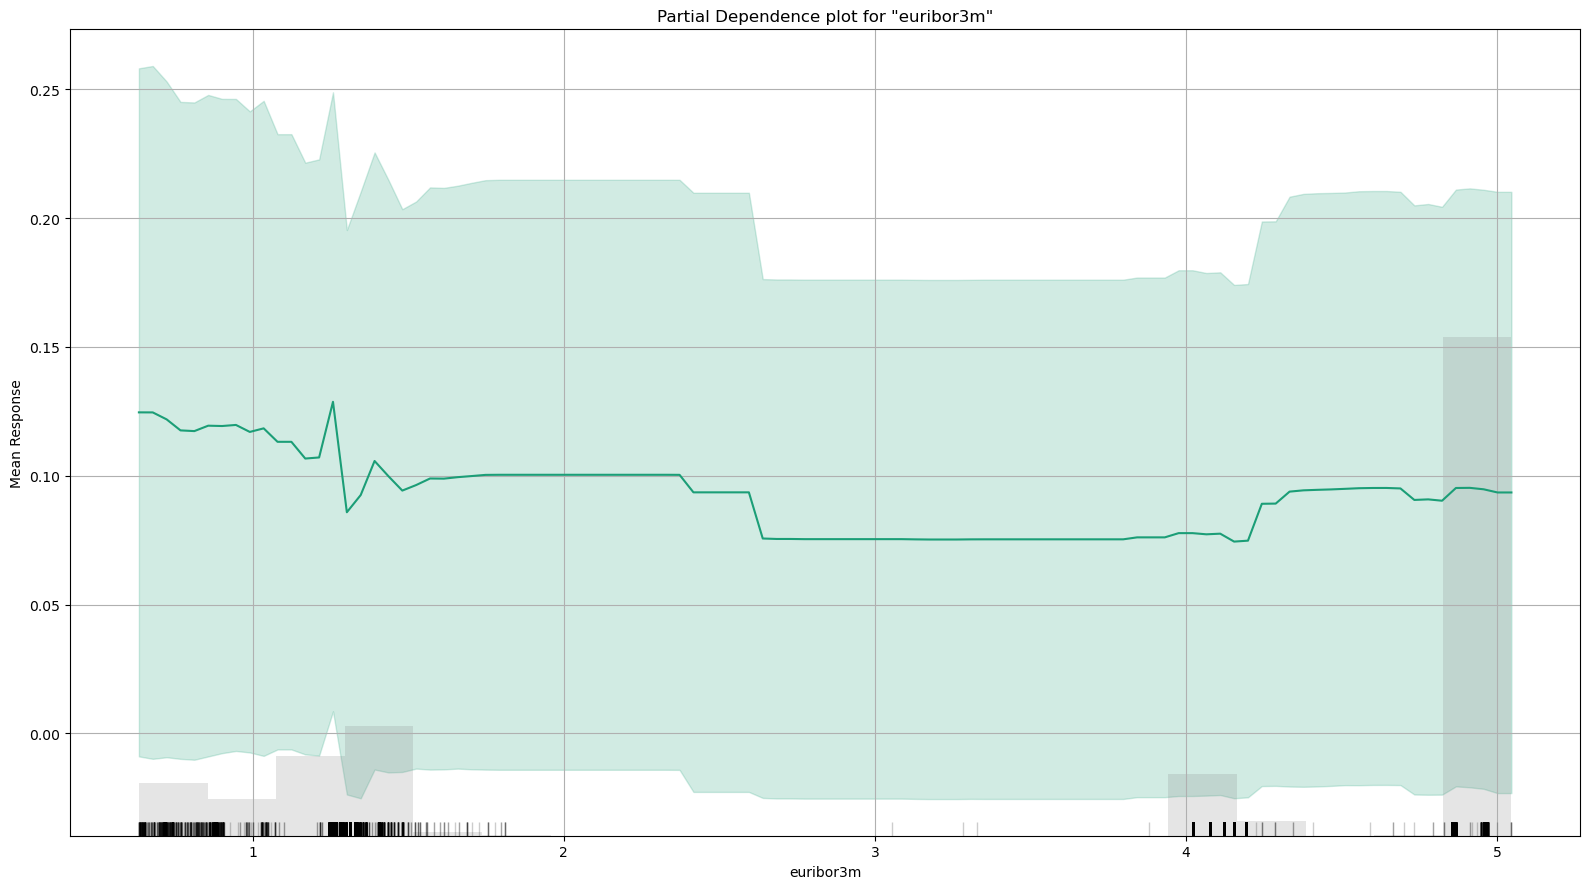

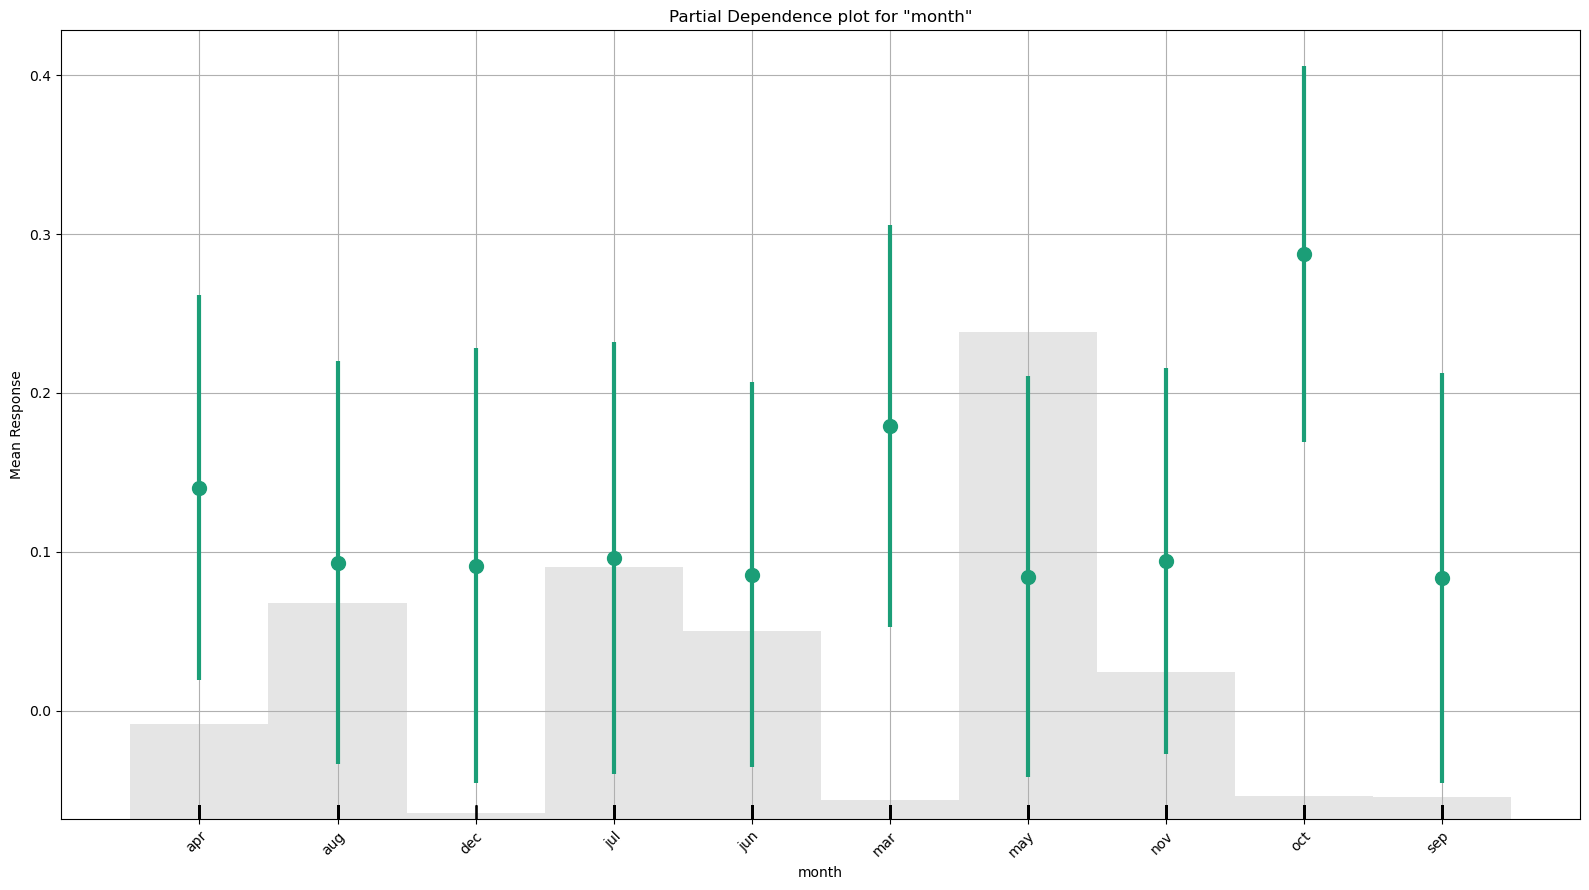

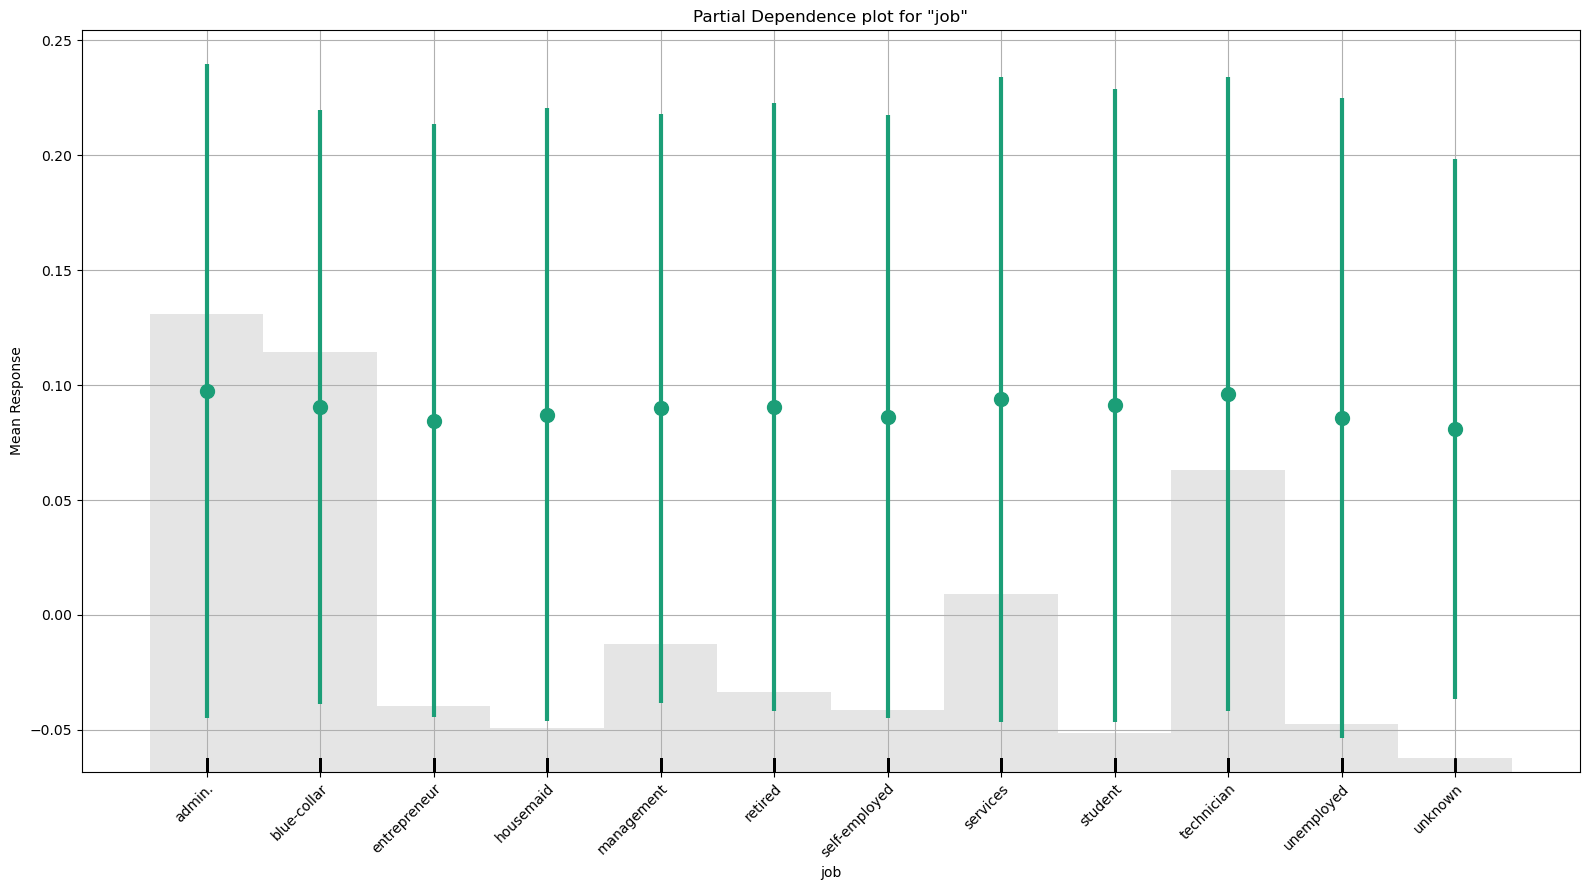

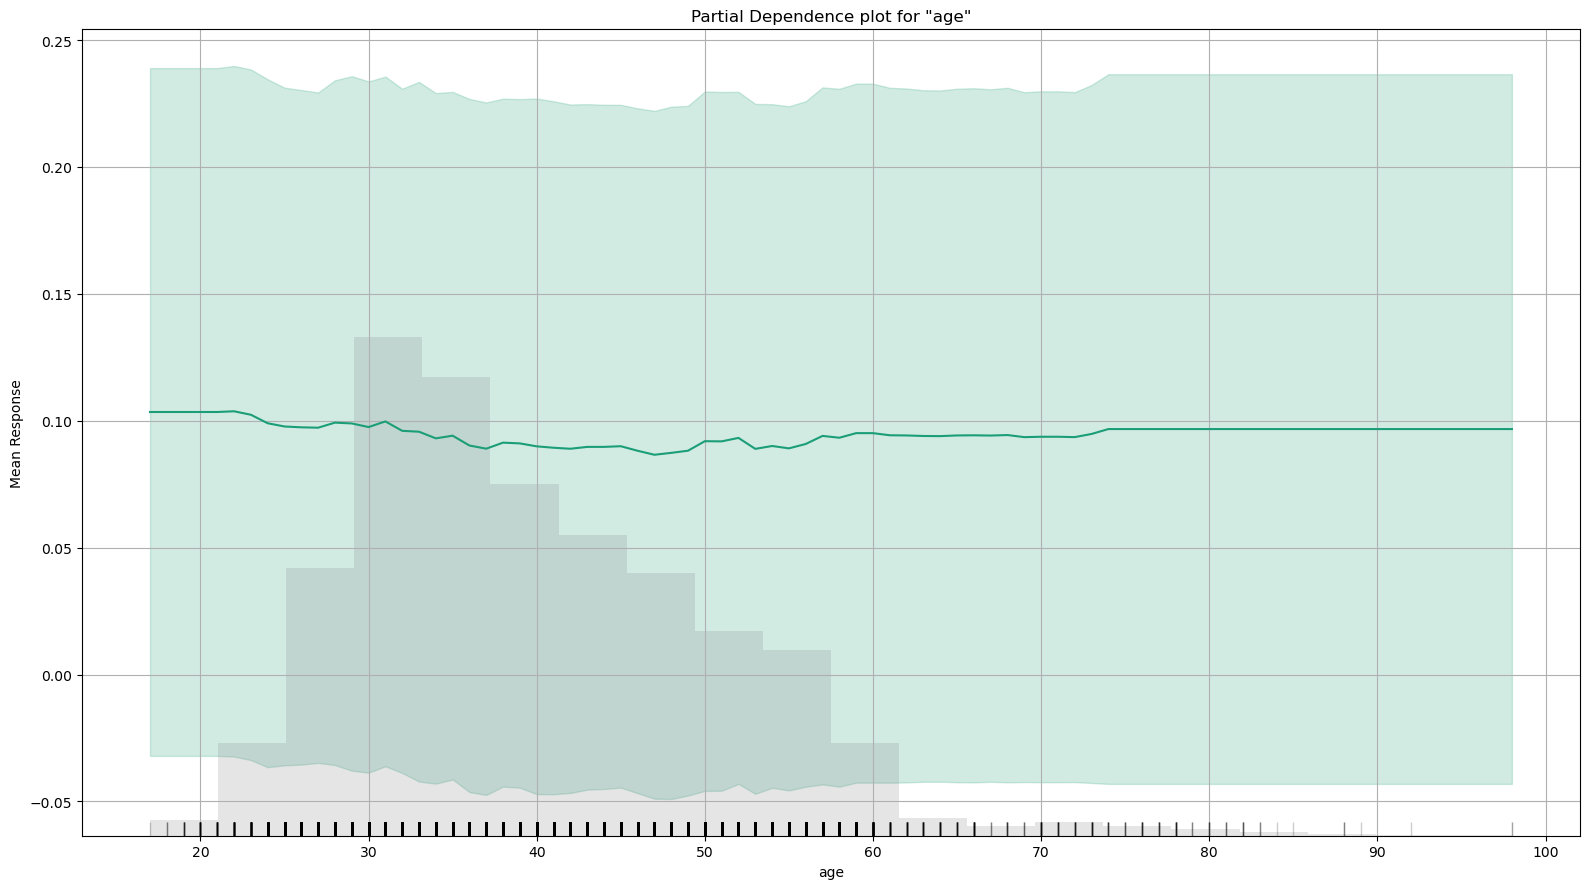



H2O session _sid_9e16 closed.


In [23]:
# 1. Inicjalizacja i dane

import h2o
from h2o.automl import H2OAutoML

h2o.init()

# 2. Załaduj dane
df = h2o.import_file(path='./Data/bank-additional-full.csv', sep=';')
df = df.drop('duration')
df['y'] = df['y'].asfactor()

# Podział na train/test
train, test = df.split_frame(ratios=[0.8], seed=42)

# 3. Trening AutoML

aml = H2OAutoML(max_models=10, seed=42, balance_classes=True, max_runtime_secs=60)
aml.train(y='y', training_frame=train, leaderboard_frame=test)

# 4. Ocena modelu lidera

best_model = aml.leader
perf = best_model.model_performance(test)

# AUC
print("AUC:", perf.auc())

# Confusion matrix
print(perf.confusion_matrix())

# 5. Wyjaśnienie modelu 

best_model.explain(test) # tu też będzie 'confusion matrix'

# 6. Zakończenie sesji

h2o.cluster().shutdown(prompt=False)